# Transfer learning with Hoplite-based embedding storage

## Run this tutorial

This tutorial is more than a reference! It's a Jupyter Notebook which you can run and modify on Google Colab or your own computer.

|Link to tutorial|How to run tutorial|
| :- | :- |
| [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kitzeslab/opensoundscape/blob/master/docs/tutorials/train_cnn.ipynb) | The link opens the tutorial in Google Colab. Uncomment the "installation" line in the first cell to install OpenSoundscape. |
| [![Download via DownGit](https://img.shields.io/badge/GitHub-Download-teal?logo=github)](https://minhaskamal.github.io/DownGit/#/home?url=https://github.com/kitzeslab/opensoundscape/blob/master/docs/tutorials/train_cnn.ipynb) | The link downloads the tutorial file to your computer. Follow the [Jupyter installation instructions](https://opensoundscape.org/en/latest/installation/jupyter.html), then open the tutorial file in Jupyter. |

In [1]:
# if this is a Google Colab notebook, install opensoundscape in the runtime environment
if 'google.colab' in str(get_ipython()):
  %pip install "opensoundscape==0.12.1" "jupyter-client<8,>=5.3.4" "ipykernel==6.17.1" "bioacoustics-model-zoo==0.12.0"
  num_workers=0
else:
  # choose cpu parallelization count
  num_workers=4

## Setup

In [2]:
%load_ext autoreload
%autoreload 2

### Import needed packages

In [3]:
#other utilities and packages
import torch
import pandas as pd
from pathlib import Path
import numpy as np
import pandas as pd
import random 
from glob import glob
import sklearn

from tqdm.autonotebook import tqdm
from sklearn.metrics import average_precision_score, roc_auc_score
from pathlib import Path

#set up plotting
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize']=[15,5] #for large visuals
%config InlineBackend.figure_format = 'retina'

# opensoundscape transfer learning tools
from opensoundscape.ml.shallow_classifier import MLPClassifier

/var/folders/d8/265wdp1n0bn_r85dh3pp95fh0000gq/T/ipykernel_53037/951004154.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


### Download and prepare training data


#### Download example files
Download a set of aquatic soundscape recordings with annotations of _Rana sierrae_ vocalizations

Option 1: run the cell below

- if you get a 403 error, DataDryad suspects you are a bot. Use Option 2. 

Option 2:

- Download and unzip the `rana_sierrae_2022.zip` folder containing audio and annotations from this [public Dryad dataset](https://datadryad.org/stash/dataset/doi:10.5061/dryad.9s4mw6mn3#readme)
- Move the unzipped `rana_sierrae_2022` folder into the current folder

In [5]:
# # Note: the "!" preceding each line below allows us to run bash commands in a Jupyter notebook
# # If you are not running this code in a notebook, input these commands into your terminal instead
# !wget -O rana_sierrae_2022.zip https://datadryad.org/stash/downloads/file_stream/2722802;
# !unzip rana_sierrae_2022;

#### Prepare audio data
See the train_cnn.ipynb tutorial for step-by-step walkthrough of this process, or just run the cells below to prepare a training set.

In [6]:
# Set this variable to specify where the folder `rana_sierrae_2022` is located:
dataset_path = Path("./rana_sierrae_2022/")

# let's generate clip labels of 5s duration (to match HawkEars) using the raven annotations
# and some utility functions from opensoundscape
from opensoundscape.annotations import BoxedAnnotations

audio_and_raven_files = pd.read_csv(f"{dataset_path}/audio_and_raven_files.csv")
# update the paths to where we have the audio and raven files stored
audio_and_raven_files["audio"] = audio_and_raven_files["audio"].apply(
    lambda x: f"{dataset_path}/{x}"
)
audio_and_raven_files["raven"] = audio_and_raven_files["raven"].apply(
    lambda x: f"{dataset_path}/{x}"
)

annotations = BoxedAnnotations.from_raven_files(
    raven_files=audio_and_raven_files["raven"],
    audio_files=audio_and_raven_files["audio"],
    annotation_column="annotation",
)
# generate labels for 5s clips, including any labels that overlap by at least 0.2 seconds
labels = annotations.clip_labels(
    clip_duration=3, min_label_overlap=0.2, final_clip=None
)

/Users/SML161/opensoundscape/opensoundscape/annotations.py:347: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_annotations_df = pd.concat(all_file_dfs).reset_index(drop=True)


#### split into training and validation data
We'll just focus on class 'C', a less-common call type that consists of repeated inharmonic notes

In [7]:
labels_train, labels_val = sklearn.model_selection.train_test_split(labels[["C"]])

Embed all samples to Hoplite database with a chosen model

In [8]:
import bioacoustics_model_zoo as bmz

birdnet = bmz.BirdNET()
birdnet.name = "BirdNET v2.4"

downloading model from URL...


In [9]:
# uncomment and run to remove existing db
# !rm -rf ./agileDB/

In [10]:
from opensoundscape.vector_database import load_or_create_hoplite_usearch_db

db = load_or_create_hoplite_usearch_db(
    "./agileDB/", embedding_dim=birdnet.classifier.in_features
)

Connecting to existing db at agileDB
Connected database has 2,016 embeddings from 672 files.


In [11]:
# use a date-parsing tool so that recording timestamps are extracted from file names
from aru_metadata_parser.parse import ARUFileTimestampParser

dt_parser = ARUFileTimestampParser(
    filename_timezone="UTC", output_timezone="US/Pacific"
)

db, failed_samples = birdnet.embed_to_hoplite_db(
    labels,
    db=db,
    deployment="rana_sierrae_2022",
    num_workers=0,
    batch_size=32,
    file_to_datetime=dt_parser.parse,
)

all samples already have embeddings in the database


In [12]:
from opensoundscape.ml.shallow_classifier import select_from_hoplite, count_dets_hoplite

select one sample of the "chuckle call" - we'll imagine this is the only sample we had to start the process with

display as click-to-play spectrogram

(if you remove the random_state, each time you run the cell it will select a different sample)


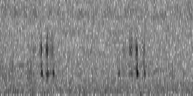

In [13]:
# start with one example of the target sound
from opensoundscape.visualization import inspect, annotate

example_clip = labels[labels["C"] == 1].sample(1, random_state=7)
_ = inspect(example_clip.reset_index(), bandpass_range=(0, 2500))

Find some samples via embedding similarity search and annotate them

annotations will be added to columns of the clips dataframe

In [14]:
# similarity search in the hoplite database
search_results = birdnet.similarity_search_hoplite_db(
    example_clip,
    db,
    num_results=20,
)
search_result_clips = pd.DataFrame(search_results[0]["results"]).reset_index()
_ = annotate(
    search_result_clips,
    bandpass_range=(0, 2500),
    annotation_buttons=["Accept", "Reject"],
    N=20,
)

embedding query samples


/Users/SML161/opensoundscape/opensoundscape/ml/cnn.py:3017: UserWarning: The columns of input samples df differ from `model.classes`. Discarding sample df columns.
  warnings.warn(


  0%|          | 0/1 [00:00<?, ?it/s]

performing similarity search for each of 1 query samples


GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

Display clip df after annotating:

In [15]:
search_result_clips

,index,file,start_time,end_time,window_id,sort_score,Accept,Reject
0,0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,451,-293.360901,None,None
1,1,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,686,-253.024963,None,None
2,2,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,450,-246.626495,None,None
3,3,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,1634,-239.828583,None,None
4,4,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,28,-231.851105,None,None
5,5,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,0.0,3.0,684,-227.285858,None,None
6,6,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,230,-223.782928,None,None
7,7,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,1862,-222.986618,None,None
8,8,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,813,-221.139206,None,None
9,9,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,1706,-220.508057,None,None


Hopefully, some of these clips can be used as positive training samples for the class of interest. We can also try starting with a different query sample. 

Now, since we want to train a binary classifier for presence and absence, let's also annotate some randomly selected clips to get a diverse set of negative examples

In [16]:
# annotate random clips
random_clips = labels.sample(20)[[]].reset_index()
_ = annotate(
    random_clips,
    bandpass_range=(0, 2500),
    annotation_buttons=["Accept", "Reject"],
    N=20,
)

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

## Train shallow classifier

We'll train our first classifiers on the labels created above

In [17]:
embedding_size = birdnet.classifier.in_features

clf = MLPClassifier(
    input_size=embedding_size,
    output_size=1,
    hidden_layer_sizes=(),
    classes=["RanaSierrae_C"],
)

Aggregate our labels into a training dataframe with:
- file, start_time, end_time in the index
- 'RanaSierrae_C' column with 0 for absent and 1 for present

In [ ]:
positive_labels = pd.concat(
    [
        search_result_clips[search_result_clips["Accept"] == True],
        random_clips[random_clips["Accept"] == True],
    ],
    ignore_index=True,
)[["file", "start_time", "end_time"]]
positive_labels["RanaSierrae_C"] = 1
negative_labels = pd.concat(
    [
        search_result_clips[search_result_clips["Reject"] == True],
        random_clips[random_clips["Reject"] == True],
    ],
    ignore_index=True,
)
negative_labels = negative_labels[["file", "start_time", "end_time"]]
negative_labels["RanaSierrae_C"] = 0
training_labels = (
    pd.concat([positive_labels, negative_labels], ignore_index=True)
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])
)
# training_labels.to_csv("round1_labels.csv")

# or re-load existing labels
# training_labels = pd.read_csv("round2_labels.csv").set_index(["file", "start_time", "end_time"])

embed the samples

In [19]:
training_db = load_or_create_hoplite_usearch_db(
    "./rasi_hawkears_train_val/", embedding_dim=birdnet.classifier.in_features
)
emb_db, failed_samples = birdnet.embed_to_hoplite_db(
    training_labels, training_db, deployment="trainval", batch_size=32
)

Connecting to existing db at rasi_hawkears_train_val
Connected database has 54 embeddings from 46 files.
all samples already have embeddings in the database


train shallow classifier

In [20]:
from opensoundscape.ml.shallow_classifier import (
    fit_on_hoplite,
    predict_on_hoplite,
)
from sklearn.model_selection import train_test_split

train, val = train_test_split(training_labels, test_size=0.5)
fit_on_hoplite(
    model=clf,
    hoplite_db=training_db,
    train_df=train,
    validation_df=val,
    steps=300,
    batch_size=128,
)

Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.
Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.
Epoch 100/300, Loss: 0.063, Val Loss: 0.190
	val AU ROC: 1.000
	val MAP: 1.000
Epoch 200/300, Loss: 0.024, Val Loss: 0.118
	val AU ROC: 1.000
	val MAP: 1.000
Epoch 300/300, Loss: 0.013, Val Loss: 0.089
	val AU ROC: 1.000
	val MAP: 1.000
Loaded best model with validation loss: 0.089 at step 300 of 300
Training complete


{'loss': 0.08942601084709167,
 'auroc': 1.0,
 'map': 1.0,
 'per_class_auroc': [1.0]}

Let's make some annotations on the most confident predictions

In [21]:
scores = predict_on_hoplite(db, labels, clf)

# don't review clips we already annotated
scores = scores.drop(index=training_labels.index)
# select top score per audio recorder to review
topk = scores.nlargest(20, "RanaSierrae_C")
topk = topk.reset_index()
_ = annotate(
    topk, bandpass_range=(0, 2500), annotation_buttons=["Accept", "Reject"], N=20
)

Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.


  0%|          | 0/2 [00:00<?, ?it/s]

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

Let's aggregate the new labels with the old training set, then refine our classifier

In [ ]:
# only use clips that were labeled
new_positives = topk[topk["Accept"] == True].copy()
new_positives["RanaSierrae_C"] = 1
new_negatives = topk[topk["Reject"] == True].copy()
new_negatives["RanaSierrae_C"] = 0
# aggregate with previous training data
train2 = (
    pd.concat([new_positives, new_negatives, train.reset_index()])
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])[["RanaSierrae_C"]]
)
# train2.to_csv("round2_labels.csv")
# or reload
# train2 = pd.read_csv("round2_labels.csv", index_col=[0, 1, 2])
print(train2.value_counts("RanaSierrae_C"))

# embed new training data
_ = birdnet.embed_to_hoplite_db(
    train2, training_db, deployment="trainval", batch_size=32
)

RanaSierrae_C
0    22
1    14
Name: count, dtype: int64
all samples already have embeddings in the database


Now, we refine the classifier using the additional labels

In [23]:
fit_on_hoplite(
    model=clf,
    hoplite_db=training_db,
    train_df=train2,
    validation_df=val,
    steps=300,
    batch_size=128,
)

Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.
Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.
Epoch 100/300, Loss: 0.005, Val Loss: 0.006
	val AU ROC: 1.000
	val MAP: 1.000
Epoch 200/300, Loss: 0.002, Val Loss: 0.002
	val AU ROC: 1.000
	val MAP: 1.000
Epoch 300/300, Loss: 0.001, Val Loss: 0.001
	val AU ROC: 1.000
	val MAP: 1.000
Loaded best model with validation loss: 0.001 at step 300 of 300
Training complete


{'loss': 0.0013997730566188693,
 'auroc': 1.0,
 'map': 1.0,
 'per_class_auroc': [1.0]}

Annotation round 2 - let's see if the classifier is honing in on the repeated-note calls

In [24]:
scores = predict_on_hoplite(db, labels, clf)

# don't review clips we already annotated
topk = scores.drop(index=training_labels.index)
# select top score per audio recorder to review
topk = topk.nlargest(20, "RanaSierrae_C")
topk = topk.reset_index()
_ = annotate(
    topk, bandpass_range=(0, 2500), annotation_buttons=["Accept", "Reject"], N=20
)

Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.


  0%|          | 0/2 [00:00<?, ?it/s]

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

Once we iterate on this a couple of times, we'll often find that the top scores look good. What if we explored the full range of scores?


In [ ]:
from opensoundscape.visualization import explore_histogram

fw = explore_histogram(scores, "RanaSierrae_C", bandpass_range=(0, 2500), N=8)

    'data': [{'name': 'all',
              'nbinsx': 30,
              'opacity'…


By looking at samples from various regions of the score histogram, it appears that:
- high scores are correct true positives
- low scores are correct true negatives
- the decision boundary around logit score = 0 has a mix

Therefore, if we aren't satisfied with performance yet, we might want to annotate clips scoring near 0

In [ ]:
# don't review clips we already annotated
uncertain_clips = scores.drop(index=training_labels.index)

# select random clips scoring between -2 and 1 to review
uncertain_clips = uncertain_clips[
    (uncertain_clips["RanaSierrae_C"] > -2) & (uncertain_clips["RanaSierrae_C"] < 1)
]
uncertain_clips = uncertain_clips.reset_index()
_ = annotate(
    uncertain_clips,
    bandpass_range=(0, 2500),
    annotation_buttons=["Accept", "Reject"],
    N=20,
)

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

refine the classifier one more time

In [ ]:
# incorporate new labels
new_positives = uncertain_clips[uncertain_clips["Accept"] == True].copy()
new_positives["RanaSierrae_C"] = 1
new_negatives = uncertain_clips[uncertain_clips["Reject"] == True].copy()
new_negatives["RanaSierrae_C"] = 0
# aggregate with previous training data
train3 = (
    pd.concat([new_positives, new_negatives, train2.reset_index()])
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])[["RanaSierrae_C"]]
)
# train3.to_csv("round3_labels.csv")
# or reload
# train3 = pd.read_csv("round3_labels.csv", index_col=[0, 1, 2])
print(train3.value_counts("RanaSierrae_C"))

# embed new training data
_ = birdnet.embed_to_hoplite_db(
    train3, training_db, deployment="trainval", batch_size=32
)
# Now, we refine the classifier using the additional labels
fit_on_hoplite(
    model=clf,
    hoplite_db=training_db,
    train_df=train3,
    validation_df=val,
    steps=300,
    batch_size=128,
)

embedding 19 new windows to database


  0%|          | 0/1 [00:00<?, ?it/s]

Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.
Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.
Epoch 100/300, Loss: 0.011, Val Loss: 0.005
	val AU ROC: 1.000
	val MAP: 1.000
Epoch 200/300, Loss: 0.006, Val Loss: 0.003
	val AU ROC: 1.000
	val MAP: 1.000
Epoch 300/300, Loss: 0.003, Val Loss: 0.002
	val AU ROC: 1.000
	val MAP: 1.000
Loaded best model with validation loss: 0.002 at step 300 of 300
Training complete


{'loss': 0.0018879384733736515,
 'auroc': 1.0,
 'map': 1.0,
 'per_class_auroc': [1.0]}

save the classifier to a file:

In [30]:
clf.save("rasi_classifier_round3.pt")

# use later:
# clf = MLPClassifier.load("rasi_classifier_round3.pt")
# field_data_db = birdnet.embed_to_hoplite_db(audio_files, 'field_data_db', deployment='field_data')
# prediction_scores = predict_on_hoplite(field_data_db, audio_files, clf)

Here we can start to see the value of challenging, rich evaluation data - our simple classifiers performed perfectly on our small/weak evaluation set in all rounds, so we can't tell if we're improving!

What does it look like to apply this classifier to data and select clips for manual review?

In [31]:
clf = MLPClassifier.load("rasi_classifier_round3.pt")


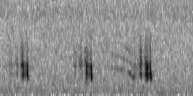
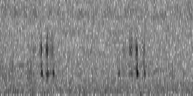
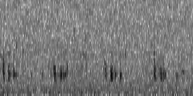
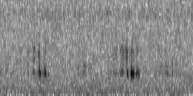
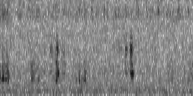

,file,start_time,end_time,datetime,deployment,project,window_id,class
0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,2022-06-22 23:15:00-07:00,rana_sierrae_2022,,685,RanaSierrae_C
1,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,2022-06-22 23:00:00-07:00,rana_sierrae_2022,,451,RanaSierrae_C
2,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,2022-06-20 11:30:00-07:00,rana_sierrae_2022,,1349,RanaSierrae_C
3,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,2022-06-24 01:15:00-07:00,rana_sierrae_2022,,1634,RanaSierrae_C
4,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,2022-06-22 23:00:00-07:00,rana_sierrae_2022,,450,RanaSierrae_C


In [ ]:
# global top 5
from opensoundscape.ml.shallow_classifier import find_matching_windows

search_results = select_from_hoplite(db, clf, classes=None)
_ = inspect(search_results, bandpass_range=(0, 2500))
search_results

Often, we want to listen across stratifications - such as 5 top scoring clips per ARU (deployment), per date window.

select_from_hoplite provides several options for filtering. We can loop over the variables of interest to select stratified clips. 

Filtering options include:
- first and last date
- earliest and latest time
- minimum and maximum score
- list of recordings (audio file paths)
- list of deployments
- list of projects

We also specify which classes we want to extract clips for, how many, and under which strategy:
- top_k: highest scoring k (eg, 5) clips matching the filters
- random_k: randomly selected k clips matching the filters
- all: all clips matching the filters

In [36]:
# Example of clip selection stratify top-k selection by recording, with a minimum score
recordings = set([r.filename for r in db.get_all_recordings()])
all_search_results = []
for r in recordings:
    search_results_df = select_from_hoplite(
        db, clf, classes=["RanaSierrae_C"], recordings=r, k=1, min_score=0
    )
    search_results_df["group"] = r
    all_search_results.append(search_results_df)
all_results = pd.concat(all_search_results, ignore_index=True)
# _=inspect(search_results_df)

/var/folders/d8/265wdp1n0bn_r85dh3pp95fh0000gq/T/ipykernel_53037/2816382862.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat(all_search_results, ignore_index=True)


Example of clip selection for all clips above a threshold

In [37]:
search_results_df = select_from_hoplite(
    db, clf, classes=["RanaSierrae_C"], strategy="all", min_score=0
)
len(search_results_df)

29

example of random clips in a score bin

we also show the use of random state to create reproducible results 

and restrict the time range

In [39]:
import datetime

search_results_df = select_from_hoplite(
    db,
    clf,
    classes=["RanaSierrae_C"],
    strategy="random_k",
    min_score=-2,
    max_score=1,
    random_state=0,
    # accepts either time strings or datetime.time objects
    time_range=("00:00:00", datetime.time(8, 0, 0)),
)
search_results_df.head(3)

,file,start_time,end_time,datetime,deployment,project,window_id,class
0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,2022-06-25 01:45:00-07:00,rana_sierrae_2022,,39,RanaSierrae_C
1,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,0.0,3.0,2022-06-21 00:15:00-07:00,rana_sierrae_2022,,705,RanaSierrae_C
2,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,0.0,3.0,2022-06-24 01:00:00-07:00,rana_sierrae_2022,,1099,RanaSierrae_C


Finally, we can also directly count the number of clips scoring in a bin, without retrieving clip information

In [42]:
import datetime

counts = count_dets_hoplite(
    db,
    clf,
    classes=["RanaSierrae_C"],
    score_bins=[(-2, -1), (-1, 0), (0, 1), (1, 2)],
)
pd.DataFrame(counts)

,,RanaSierrae_C
-2,-1,22
-1,0,7
0,1,8
1,2,2


In [ ]:
# clean up by deleting files and folders generated in this tutorial (uncomment to run)
# import shutil

# shutil.rmtree("./agileDB/")
# shutil.rmtree("./rasi_hawkears_train_val/")
# import os

# os.remove("round1_labels.csv")
# os.remove("round2_labels.csv")
# os.remove("round3_labels.csv")
# os.remove("rasi_classifier_round3.pt")